In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import scanpy as sc
import spottedpy as sp

In [4]:
sc.settings.set_figure_params(frameon=False, vector_friendly=True)
sc.settings._vector_friendly = False

In [5]:
adata = sc.read_h5ad("data/adata_with_signatures_and_hotspots.h5ad")

In [6]:
adata = adata[adata.obs["subtype"] == "Basal"].copy()

In [7]:
# Cell type labels
cell_type_labels = [
    "B cells Memory",
    "B cells Naive",
    "CAFs MSC iCAF-like s1",
    "CAFs MSC iCAF-like s2",
    "CAFs Transitioning s3",
    "CAFs myCAF like s4",
    "CAFs myCAF like s5",
    "Cycling PVL",
    "Cycling_Myeloid",
    "Endothelial ACKR1",
    "Endothelial CXCL12",
    "Endothelial Lymphatic LYVE1",
    "Endothelial RGS5",
    "Myeloid_c0_DC_LAMP3",
    "Myeloid_c10_Macrophage_1_EGR1",
    "Myeloid_c11_cDC2_CD1C",
    "Myeloid_c12_Monocyte_1_IL1B",
    "Myeloid_c1_LAM1_FABP5",
    "Myeloid_c2_LAM2_APOE",
    "Myeloid_c3_cDC1_CLEC9A",
    "Myeloid_c4_DCs_pDC_IRF7",
    "Myeloid_c5_Macrophage_3_SIGLEC1",
    "Myeloid_c7_Monocyte_3_FCGR3A",
    "Myeloid_c8_Monocyte_2_S100A9",
    "Myeloid_c9_Macrophage_2_CXCL10",
    "PVL Differentiated s3",
    "PVL Immature s1",
    "PVL_Immature s2",
    "Plasmablasts",
    "T_cells_c0_CD4+_CCR7",
    "T_cells_c10_NKT_cells_FCGR3A",
    "T_cells_c11_MKI67",
    "T_cells_c1_CD4+_IL7R",
    "T_cells_c2_CD4+_T-regs_FOXP3",
    "T_cells_c3_CD4+_Tfh_CXCL13",
    "T_cells_c4_CD8+_ZFP36",
    "T_cells_c5_CD8+_GZMK",
    "T_cells_c6_IFIT1",
    "T_cells_c7_CD8+_IFNG",
    "T_cells_c8_CD8+_LAG3",
    "T_cells_c9_NK_cells_AREG"
]

quiescence_labels = ["G0_arrested", "Fast_cycling", "Slow_cycling"]
labels = cell_type_labels + ["Slow_cycling"]

In [8]:
cell_type_labels_hotspots = [label + "_hot" for label in cell_type_labels]

In [9]:
primary_variables = ["G0_arrested_hot", "Fast_cycling_hot"]
comparison_variables = cell_type_labels_hotspots

distances = sp.calculateDistances(
    adata,
    primary_variables=primary_variables,
    comparison_variables=comparison_variables,
    empty_hotspot_default_to_max_distance=False,
    split_by_slide_in_batch=True,
    hotspot_number=True
)

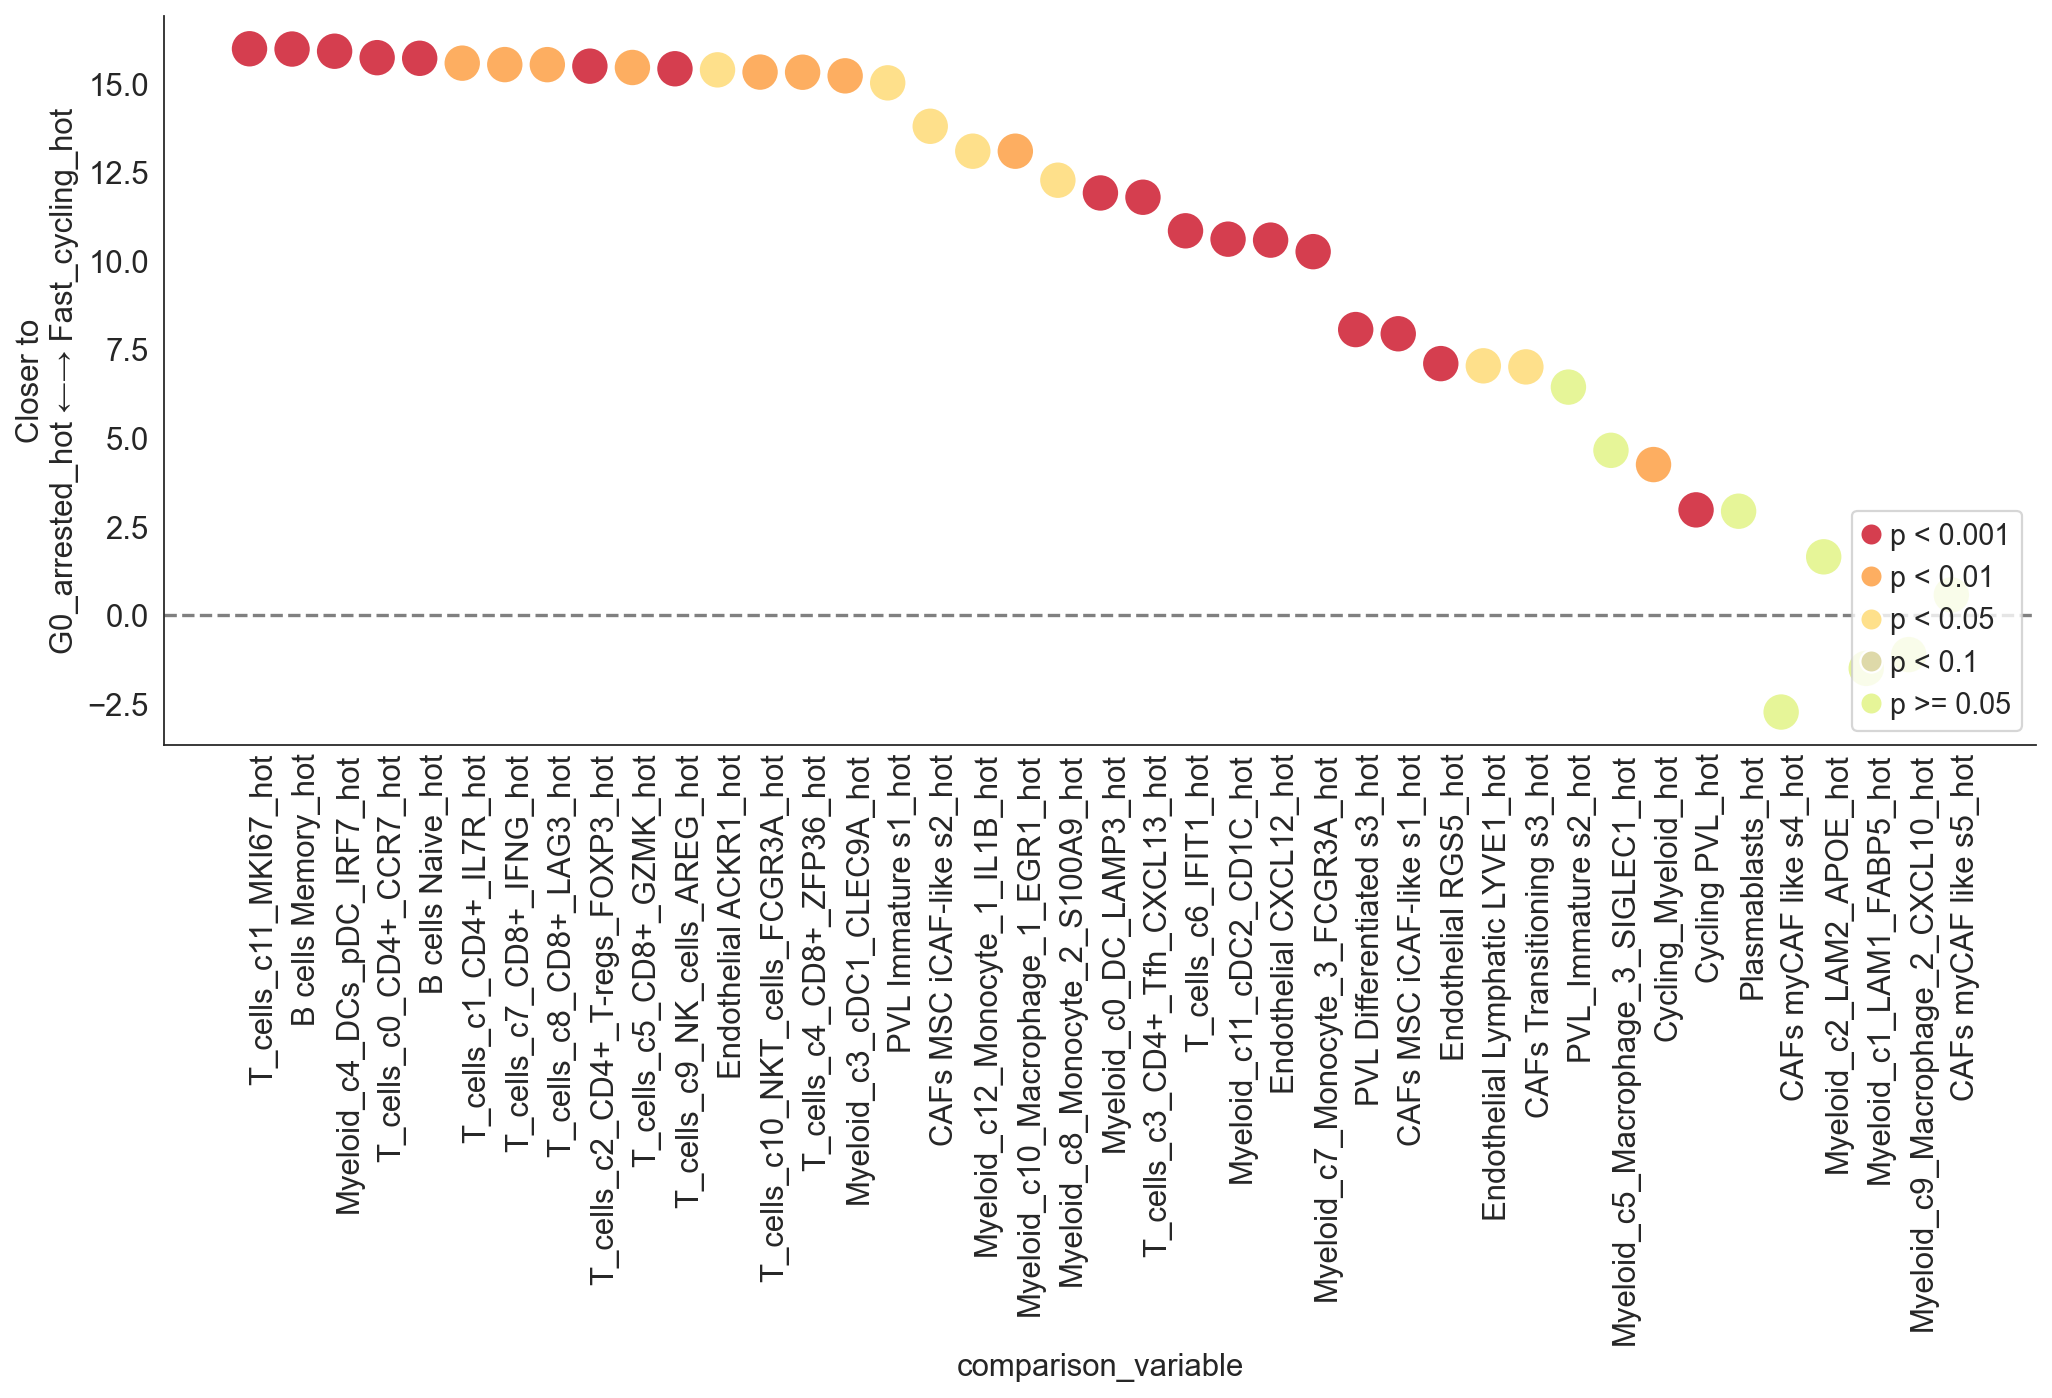

In [11]:
sp.plot_custom_scatter(
    data=distances,
    primary_vars=primary_variables,
    comparison_vars=comparison_variables,
    bubble_size=(300, 300),
    fig_size=(15, 6),
    save_path="figures/distances_per_batch_basal.pdf",
    compare_distribution_metric="median",
)

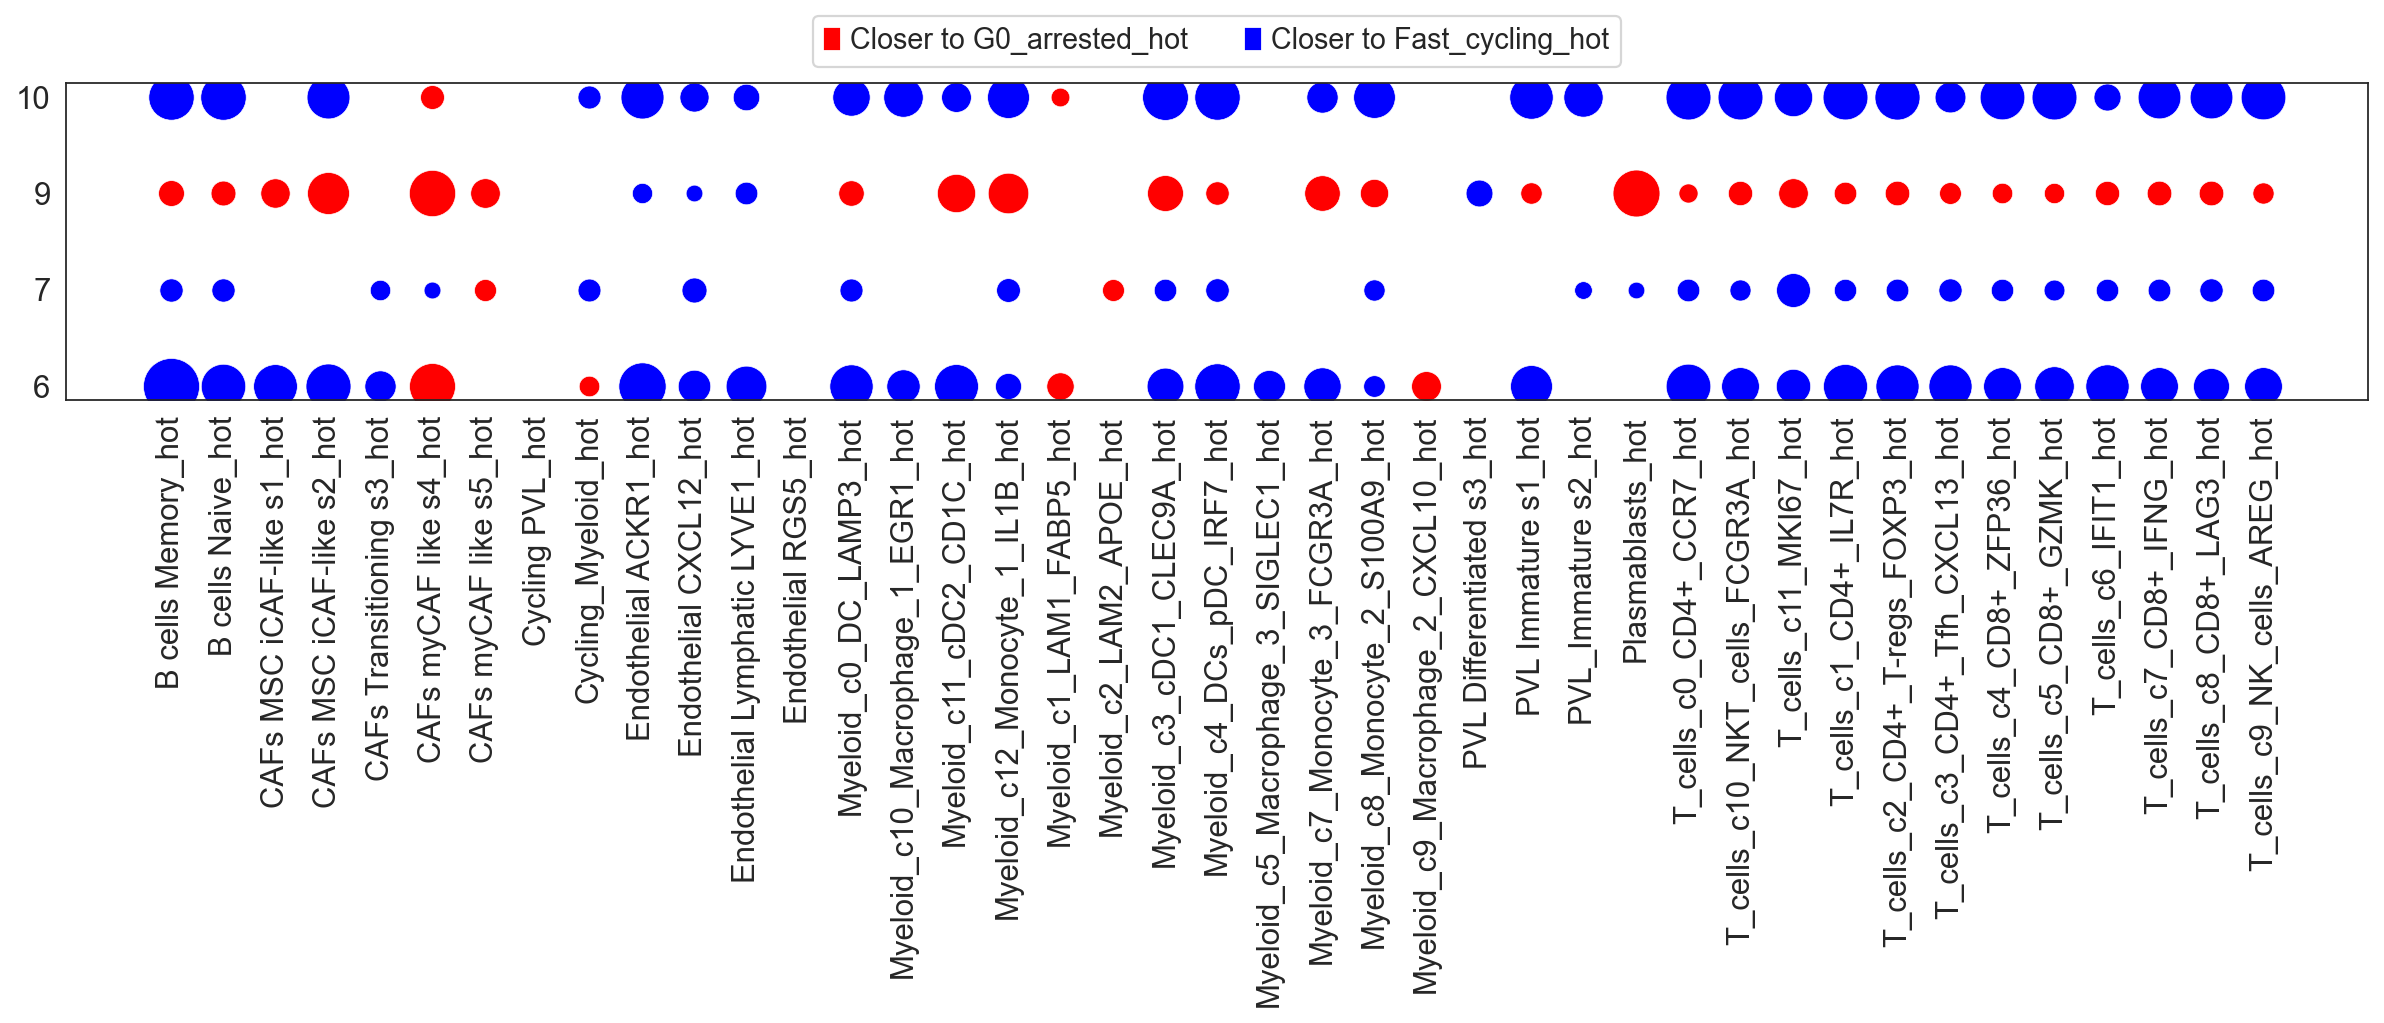

In [36]:
data = sp.plot_bubble_chart_by_batch(
    distances,
    primary_variable_value="G0_arrested_hot",
    reference_variable="Fast_cycling_hot",
    comparison_variable_values=comparison_variables,
    save_path="figures/spottedpy_distances_per_batch_Basal.pdf",
    pval_cutoff=0.05,
    fig_size=(15, 7),
)

In [12]:
from plot_multiple_hotspots import plot_multiple_hotspots

In [13]:
adata.obs["batch"].unique()

['6', '7', '9', '10']
Categories (4, object): ['6', '7', '9', '10']

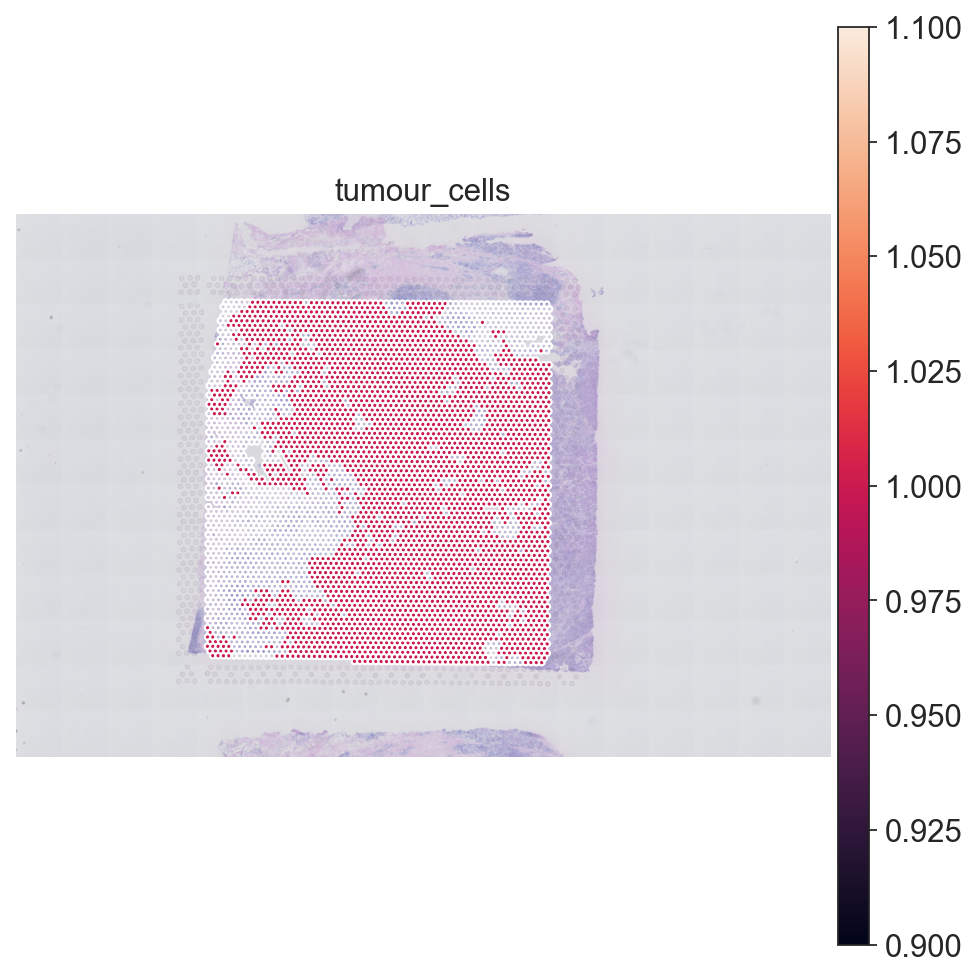

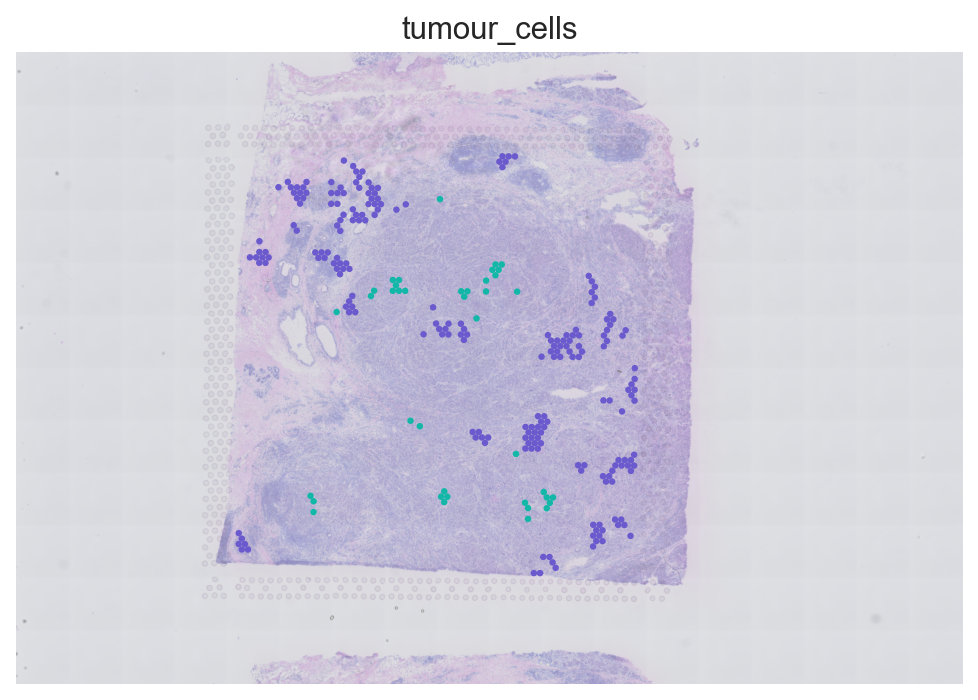

In [51]:
import squidpy as sq

sq.pl.spatial_scatter(
    adata,
    color="tumour_cells",
    library_id="7",
    library_key="batch",
    figsize=(6, 6),
    legend_loc=None,
    img_alpha=0.5,
    size=1.6,
    save="spottedpy_tumour_cells_Basal.pdf",
)

plot_multiple_hotspots(
    adata,
    signatures=["G0_arrested_hot", "Fast_cycling_hot"],
    combined_col="tumour_cells",
    palette={
        "G0_arrested_hot": "#6A5ACD",
        "Fast_cycling_hot": "#12B7A8",
        "tumour_cells": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "spottedpy_tumour_cells_Basal_2.pdf",
    },
)

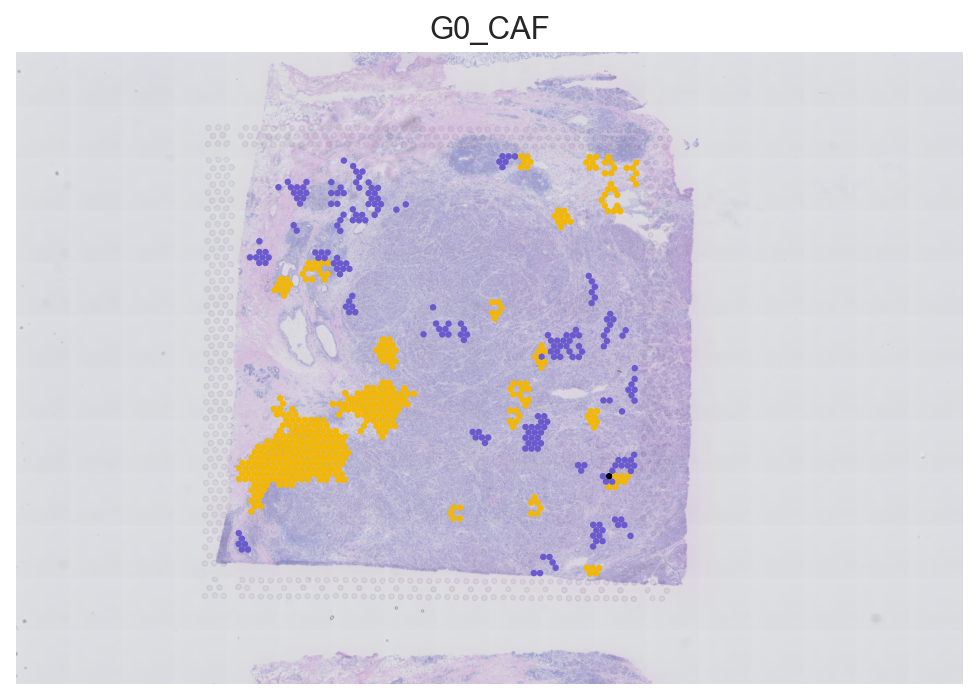

In [53]:
plot_multiple_hotspots(
    adata,
    signatures=["G0_arrested_hot", "CAFs myCAF like s4_hot"],
    combined_col="G0_CAF",
    palette={
        "G0_arrested_hot": "#6A5ACD",
        "CAFs myCAF like s4_hot": "#F2B705",
        "CAFs myCAF like s4_hot+G0_arrested_hot": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "figures/spottedpy_G0_CAF_Basal.pdf",
    },
)

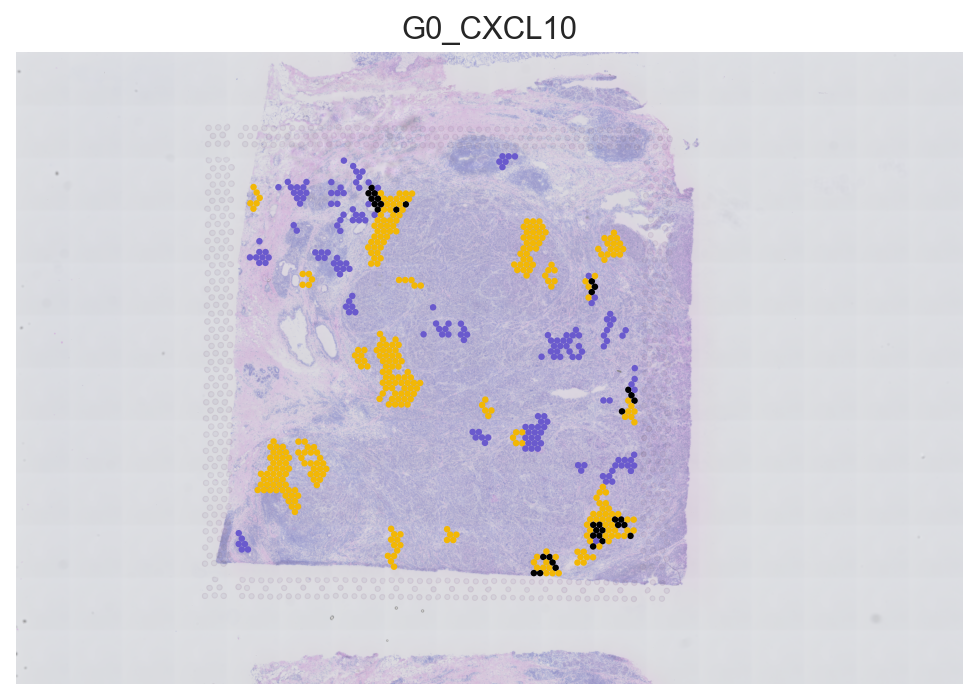

In [34]:
plot_multiple_hotspots(
    adata,
    signatures=["G0_arrested_hot", "Myeloid_c9_Macrophage_2_CXCL10_hot"],
    combined_col="G0_CXCL10",
    palette={
        "G0_arrested_hot": "#6A5ACD",
        "Myeloid_c9_Macrophage_2_CXCL10_hot": "#F2B705",
        "G0_arrested_hot+Myeloid_c9_Macrophage_2_CXCL10_hot": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "figures/spottedpy_G0_CXCL10_Basal.pdf",
    },
)

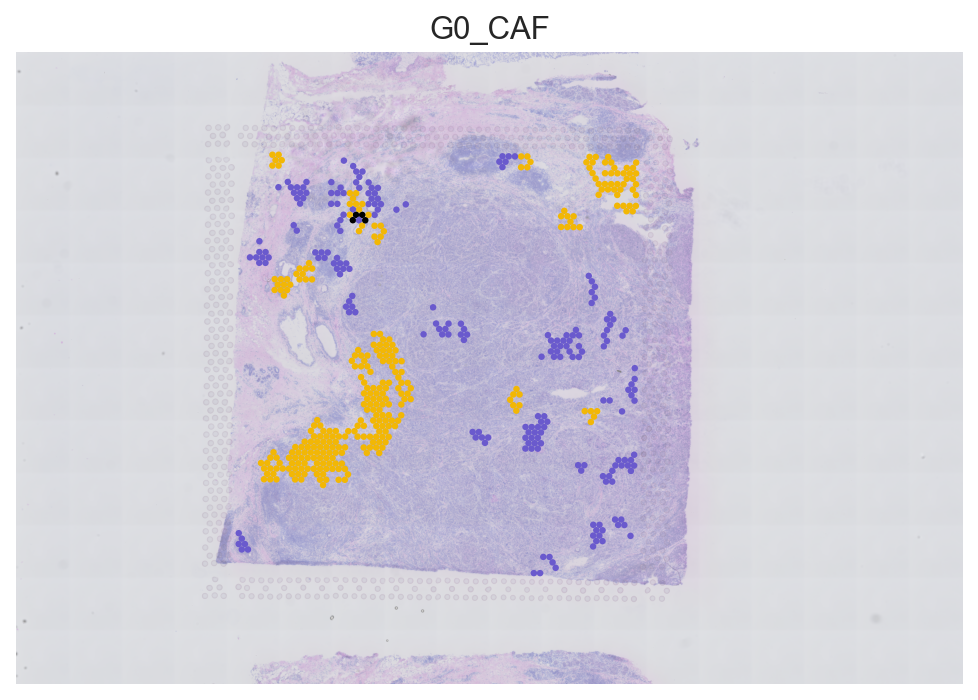

In [50]:
plot_multiple_hotspots(
    adata,
    signatures=["G0_arrested_hot", "CAFs myCAF like s5_hot"],
    combined_col="G0_CAF",
    palette={
        "G0_arrested_hot": "#6A5ACD",
        "CAFs myCAF like s5_hot": "#F2B705",
        "CAFs myCAF like s5_hot+G0_arrested_hot": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "figures/spottedpy_G0_CAF_Basal.pdf",
    },
)

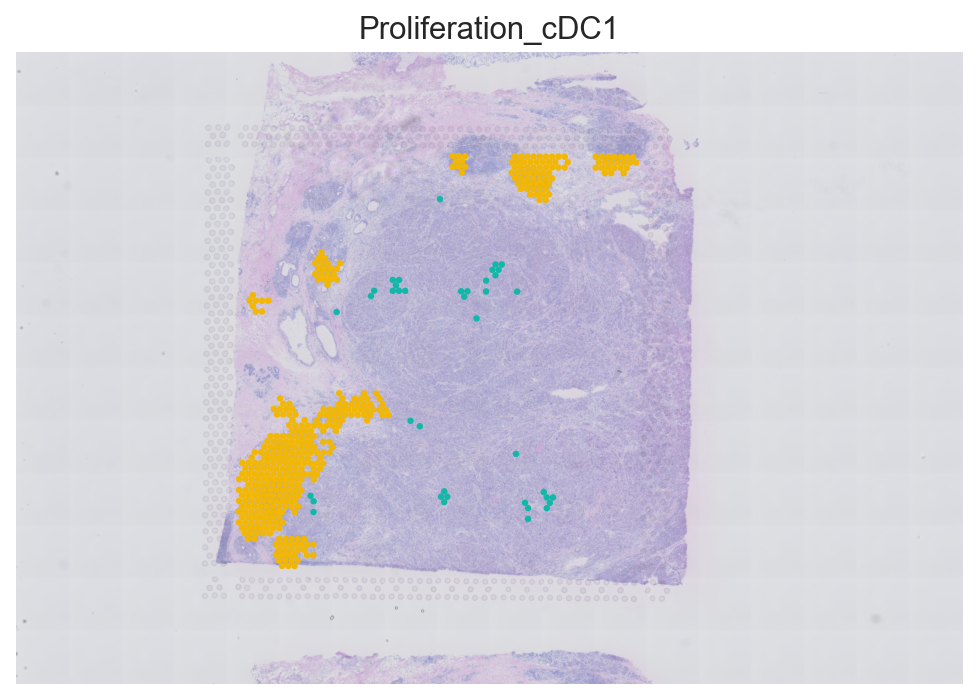

In [54]:
plot_multiple_hotspots(
    adata,
    signatures=["Fast_cycling_hot", "Myeloid_c3_cDC1_CLEC9A_hot"],
    combined_col="Proliferation_cDC1",
    palette={
        "Fast_cycling_hot": "#12B7A8",
        "Myeloid_c3_cDC1_CLEC9A_hot": "#F2B705",
        "Fast_cycling_hot+Myeloid_c3_cDC1_CLEC9A_hot": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "spottedpy_Proliferation_cDC1_Basal.pdf",
    },
)

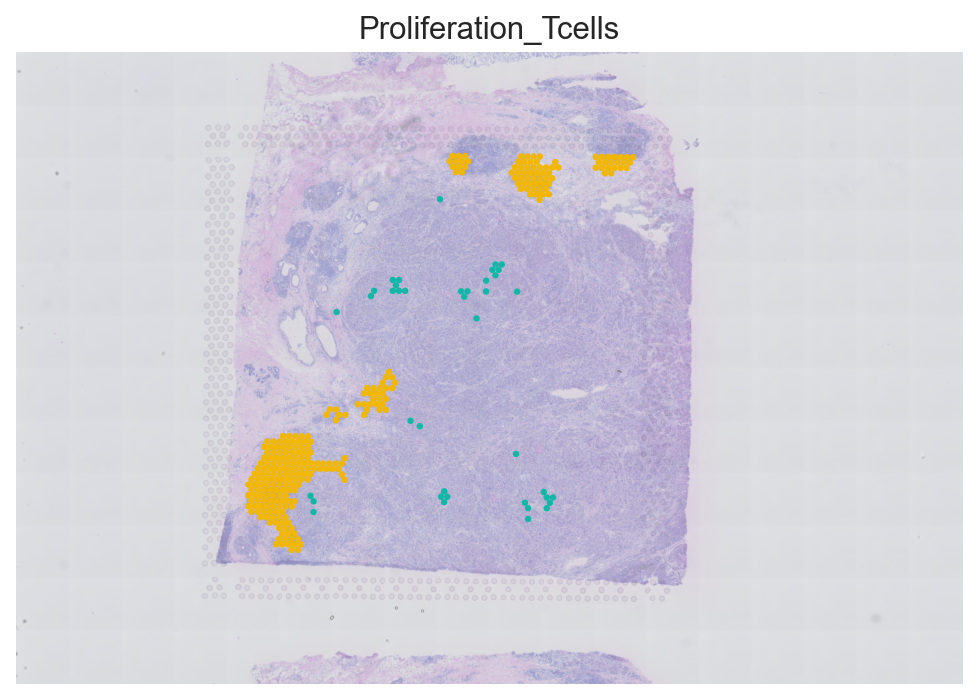

In [33]:
plot_multiple_hotspots(
    adata,
    signatures=["Fast_cycling_hot", "T_cells_c11_MKI67_hot"],
    combined_col="Proliferation_Tcells",
    palette={
        "Fast_cycling_hot": "#12B7A8",
        "T_cells_c11_MKI67_hot": "#F2B705",
        "Fast_cycling_hot+T_cells_c11_MKI67_hot": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "figures/spottedpy_Proliferation_Tcells_Basal.pdf",
    },
)

In [37]:
# Signature labels
signature_labels = [
    "Hypoxia_hallmarks",
    "Angiogenesis_hallmarks",
    "EMT_hallmarks",
    "Hybrid_EMT",
    "Mesenchymal",
    "Epithelial",
    "UPR_hallmarks",
    "IRE1_pathway",
    "PERK_pathway",
    "ATF6_pathway",
    "Semaphorin_Plexin",
    "Necrosis",
    "Apoptosis",
    "Complement",
    "Exhaustion"
]

quiescence_labels = ["G0_arrested","Fast_cycling", "Slow_cycling"]

In [38]:
signature_labels_hotspots = [label + "_hot" for label in signature_labels]

In [39]:
# Define primary and comparison variables
primary_variables = ["G0_arrested_hot", "Fast_cycling_hot"]
comparison_variables = signature_labels_hotspots

# Calculate distances
distances = sp.calculateDistances(
    adata,
    primary_variables=primary_variables,
    comparison_variables=comparison_variables,
    empty_hotspot_default_to_max_distance=False,
    split_by_slide_in_batch=True,
    hotspot_number=True,
)

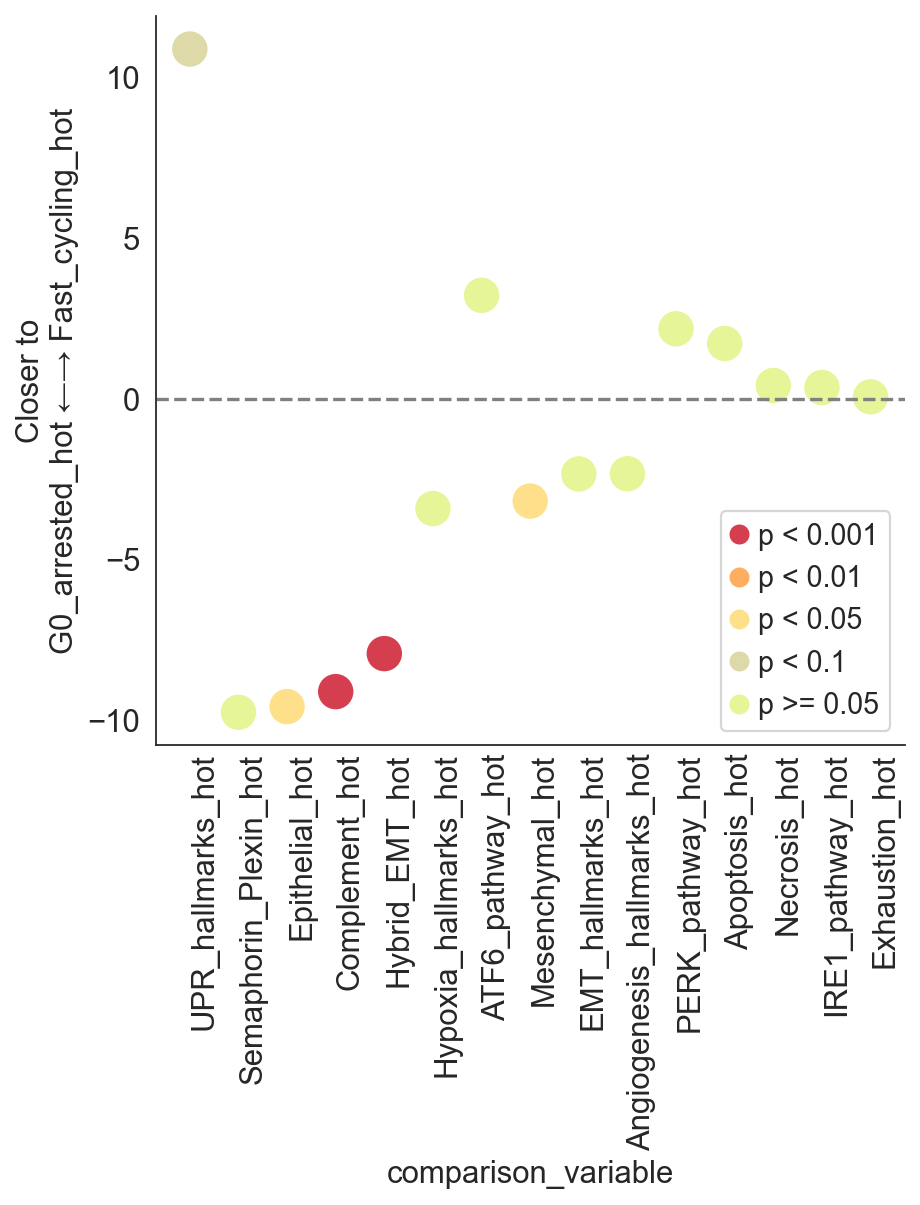

In [40]:
sp.plot_custom_scatter(
    data=distances,
    primary_vars=primary_variables,
    comparison_vars=comparison_variables,
    bubble_size=(300, 300),
    fig_size=(6, 6),
    save_path=None,
    compare_distribution_metric="median",
)

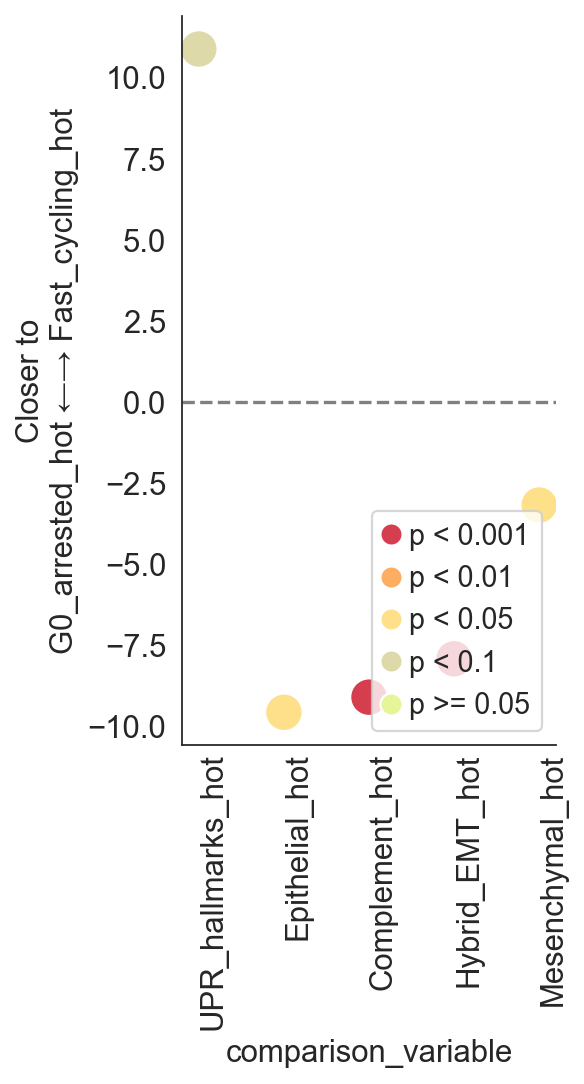

In [41]:
selected_signatures = [
    "UPR_hallmarks_hot",
    "Complement_hot",
    "Epithelial_hot",
    "Hybrid_EMT_hot",
    "Mesenchymal_hot",
]

sp.plot_custom_scatter(
    data=distances,
    primary_vars=primary_variables,
    comparison_vars=selected_signatures,
    bubble_size=(300, 300),
    fig_size=(3, 6),
    save_path="figures/spottedpy_Basal_signatures.pdf",
    compare_distribution_metric="median",
)

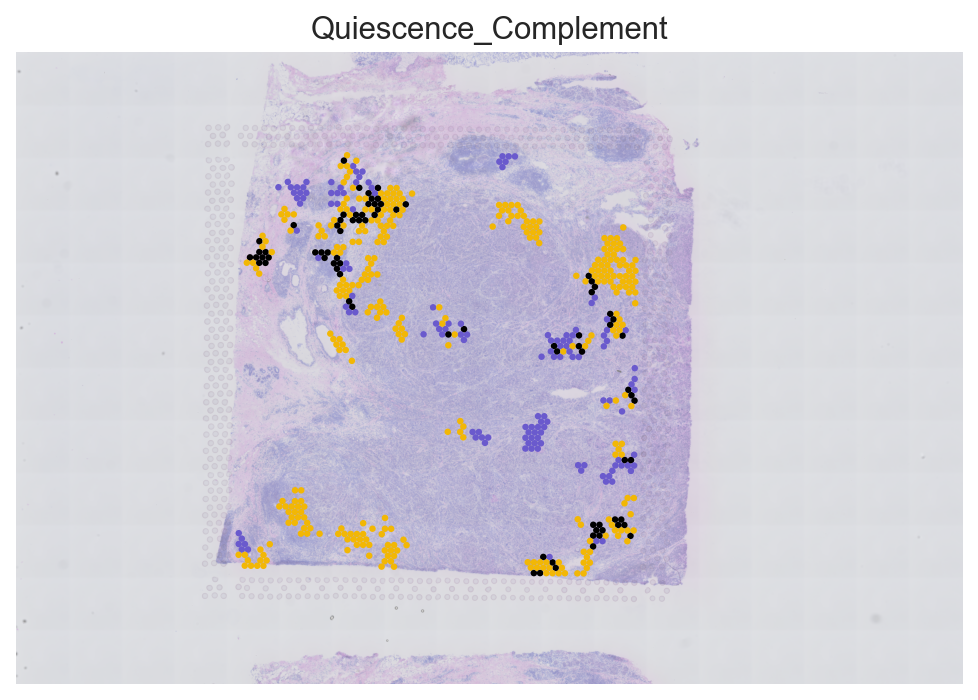

In [45]:
plot_multiple_hotspots(
    adata,
    signatures=["G0_arrested_hot", "Complement_hot"],
    combined_col="Quiescence_Complement",
    palette={
        "G0_arrested_hot": "#6A5ACD",
        "Complement_hot": "#F2B705",
        "Complement_hot+G0_arrested_hot": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "figures/spottedpy_Quiescence_Complement_Basal.pdf",
    },
)

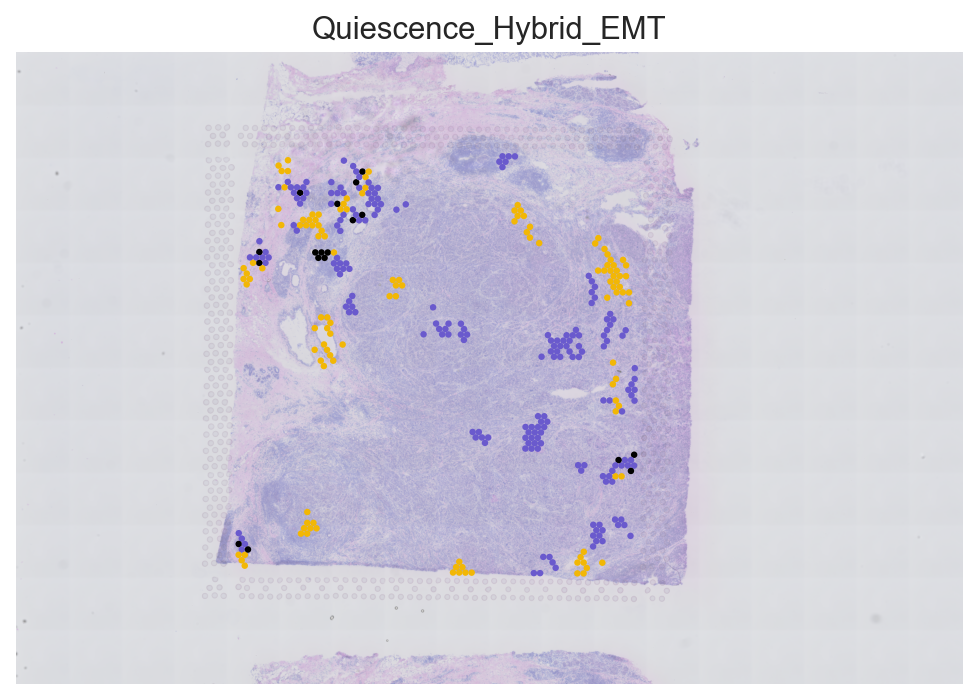

In [46]:
plot_multiple_hotspots(
    adata,
    signatures=["G0_arrested_hot", "Hybrid_EMT_hot"],
    combined_col="Quiescence_Hybrid_EMT",
    palette={
        "G0_arrested_hot": "#6A5ACD",
        "Hybrid_EMT_hot": "#F2B705",
        "G0_arrested_hot+Hybrid_EMT_hot": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "figures/spottedpy_Quiescence_Hybrid_EMT_Basal.pdf",
    },
)

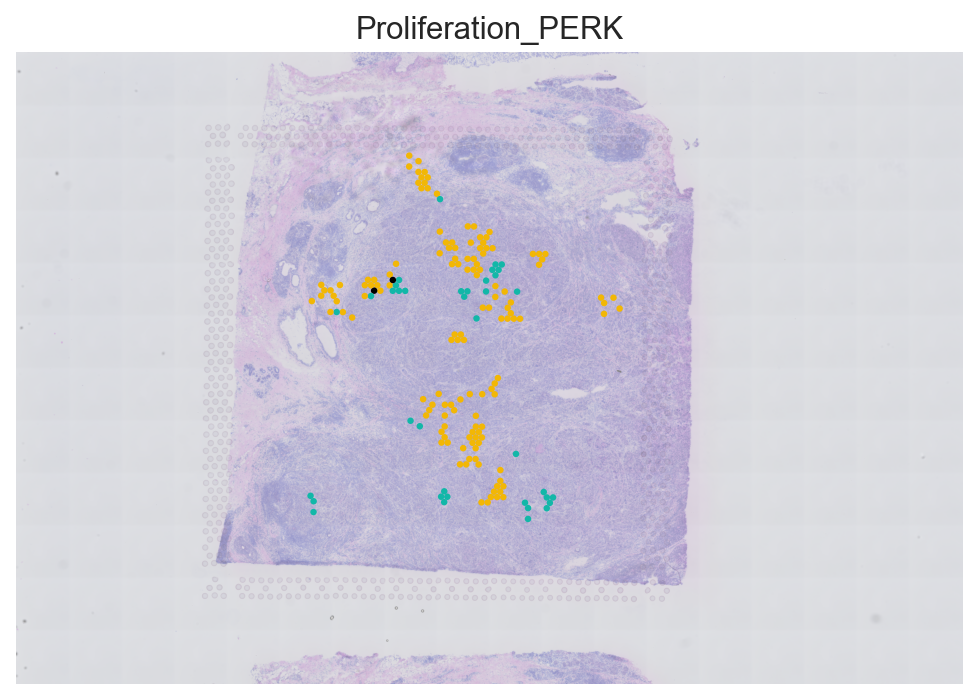

In [55]:
plot_multiple_hotspots(
    adata,
    signatures=["Fast_cycling_hot", "PERK_pathway_hot"],
    combined_col="Proliferation_PERK",
    palette={
        "Fast_cycling_hot": "#12B7A8",
        "PERK_pathway_hot": "#F2B705",
        "Fast_cycling_hot+PERK_pathway_hot": "#000000",
    },
    plot_kwargs={
        "library_id": "7",
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "spottedpy_Proliferation_PERK_Basal.pdf",
    },
)